# Custom Image Captioning Model on Flickr8k
This notebook covers the full end-to-end pipeline to train a custom **Encoder-Decoder (ResNet + LSTM)** architecture on the official **Flickr8k Dataset**.

It handles:
1. Downloading and extracting the dataset.
2. Building a Custom Vocabulary for text tokenization.
3. Creating PyTorch `Dataset` and `DataLoader` classes with a custom `collate_fn` to handle variable sequence lengths.
4. Defining the Model.
5. The Training Loop.

In [1]:
import os
import urllib.request
from zipfile import ZipFile
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# THIS DISABLES THE BUGGY MIOpen BACKEND FOR AMD WINDOWS
import torch.backends.cudnn as cudnn
cudnn.enabled = False
cudnn.benchmark = False


Using device: cuda


---
## 1. Download Flickr8k Dataset
This cell will download the image dataset (~1GB) and the text captions if they are not already present.

In [2]:
datasets_dir = 'flickr8k'
os.makedirs(datasets_dir, exist_ok=True)

url_images = 'https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip'
url_texts = 'https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip'

if not os.path.exists(os.path.join(datasets_dir, 'Flicker8k_Dataset')):
    print("Downloading Images (this might take a few minutes)...")
    urllib.request.urlretrieve(url_images, os.path.join(datasets_dir, 'Flickr8k_Dataset.zip'))
    with ZipFile(os.path.join(datasets_dir, 'Flickr8k_Dataset.zip'), 'r') as zip_ref:
        zip_ref.extractall(datasets_dir)
    print("Images extracted!")
        
if not os.path.exists(os.path.join(datasets_dir, 'Flickr8k.token.txt')):
    print("Downloading Captions...")
    urllib.request.urlretrieve(url_texts, os.path.join(datasets_dir, 'Flickr8k_text.zip'))
    with ZipFile(os.path.join(datasets_dir, 'Flickr8k_text.zip'), 'r') as zip_ref:
        zip_ref.extractall(datasets_dir)
    print("Captions extracted!")
        
print("Dataset is ready!")

Dataset is ready!


---
## 2. Vocabulary & Data Loading
We need to parse the captions file, tokenize the sentences, and map string words to integer IDs using `<PAD>`, `<SOS>`, `<EOS>`, and `<UNK>` tokens.

In [3]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold
        
    def __len__(self):
        return len(self.itos)
    
    @staticmethod
    def tokenizer_eng(text):
        return [tok.lower() for tok in text.strip().split()]
    
    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
                    
    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenized_text]

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.transform = transform
        
        with open(captions_file, 'r') as f:
            lines = f.readlines()
            
        self.imgs = []
        self.captions = []
        for line in lines:
            tokens = line.split('\t')
            if len(tokens) < 2:
                continue
            self.imgs.append(tokens[0].split('#')[0])
            self.captions.append(tokens[1].strip())
            
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions)
        
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        
        if self.transform is not None:
            img = self.transform(img)
            
        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])
        
        return img, torch.tensor(numericalized_caption)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
        
    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        
        targets = [item[1] for item in batch]
        # Pad the targets dynamically to max length in the batch
        targets = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)
        return imgs, targets

In [4]:
# Define Image Transformations (Resizing, Normalization for ResNet)
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Initialize Dataset & DataLoader
dataset = FlickrDataset(
    root_dir=os.path.join(datasets_dir, 'Flicker8k_Dataset'),
    captions_file=os.path.join(datasets_dir, 'Flickr8k.token.txt'),
    transform=transform
)

pad_idx = dataset.vocab.stoi["<PAD>"]

loader = DataLoader(
    dataset=dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx=pad_idx),
)

print(f"Dataset loaded with {len(dataset)} items.")
print(f"Vocabulary size: {len(dataset.vocab)}")

Dataset loaded with 40455 items.
Vocabulary size: 3005


---
## 3. Define the Encoder-Decoder Architecture

In [5]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        try:
            resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        except:
            resnet = models.resnet50(pretrained=True)
            
        for param in resnet.parameters():
            param.requires_grad_(False) # Freeze resnet
            
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.embed = nn.Linear(resnet.fc.in_features, embed_size)
        
    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.embed(features)
        return features

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, features, captions):
        embeddings = self.embed(captions[:, :-1]) # Ignore EOS
        embeddings = torch.cat((features.unsqueeze(1), embeddings), 1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs

---
## 4. Initialization and Training Loop
Now we pass the data through our pipeline and compute gradients! 

In [11]:
# Hyperparameters
embed_size = 256
hidden_size = 256
vocab_size = len(dataset.vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 3

# Initialize the Models 
encoder = EncoderCNN(embed_size).to(device)
decoder = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(list(encoder.embed.parameters()) + list(decoder.parameters()), lr=learning_rate)

# Automatic Mixed Precision (AMP) Scaler
scaler = torch.amp.GradScaler('cuda')


In [ ]:
print("Starting Training...")
encoder.train()
decoder.train()

for epoch in range(num_epochs):
    for idx, (imgs, captions) in enumerate(loader):
        imgs = imgs.to(device)
        captions = captions.to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            features = encoder(imgs)
            outputs = decoder(features, captions)
            loss = criterion(outputs.view(-1, vocab_size), captions.view(-1))
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        if idx % 10 == 0:
            print(f"Epoch: {epoch+1}/{num_epochs} | Step [{idx}/{len(loader)}] | Loss: {loss.item():.4f}")
            
print("Training Completed block!")


In [ ]:
# Save the trained weights to your drive
torch.save(encoder.state_dict(), 'encoder_weights.pth')
torch.save(decoder.state_dict(), 'decoder_weights.pth')
print("Model successfully saved to your hard drive!")


Model successfully saved to your hard drive!


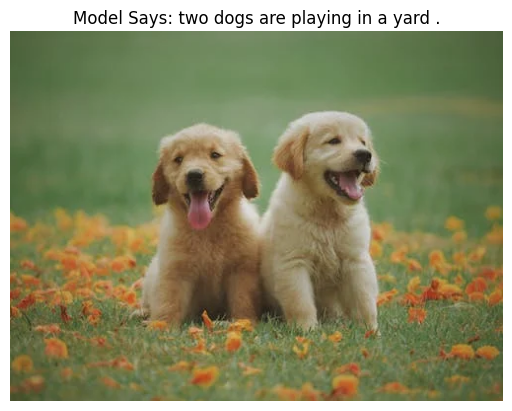

In [ ]:
def generate_caption(image_tensor, encoder, decoder, vocab, max_length=20):
    result_caption = []
    
    with torch.no_grad():
        encoder.eval()
        decoder.eval()
        
        # 1. Look at the image and extract the 256-dimension features
        features = encoder(image_tensor.to(device)).unsqueeze(1)
        
        # 2. To start the LSTM, the very first input is the Image feature itself.
        inputs = features
        states = None 
        
        for _ in range(max_length):
            hiddens, states = decoder.lstm(inputs, states)
            outputs = decoder.linear(hiddens.squeeze(1))
            
            predicted_id = outputs.argmax(1).item()
            predicted_word = vocab.itos[predicted_id]
            
            if predicted_word == "<EOS>":
                break
                
            if predicted_word != "<SOS>":
                result_caption.append(predicted_word)
                
            inputs = decoder.embed(torch.tensor([predicted_id]).to(device)).unsqueeze(1)
            
    return " ".join(result_caption)

def test_external_image(image_path, encoder, decoder, dataset):
    # Load your raw real-world image from the file path
    try:
        raw_img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Error loading image: {e}")
        return
    
    # Apply the exact PyTorch transformations used during training
    tensor_img = dataset.transform(raw_img).unsqueeze(0)
    
    # Generate the caption using our inference function
    caption = generate_caption(tensor_img, encoder, decoder, dataset.vocab)
    
    # Display the image and the generated caption
    plt.imshow(raw_img)
    plt.axis('off')
    plt.title(f"Model Says: {caption}")
    plt.show()


test_external_image('image.png', encoder, decoder, dataset)
